# 01 — Exploratory Data Analysis

**TFM: Demand Forecasting for Inventory Management Using Machine Learning**

Author: Ona Mas i Serra

This notebook performs the initial exploration of the dataset provided by the thesis supervisor.
The dataset corresponds to real historical data from a company operating in the automotive sector,
containing daily demand records for 861 products over 731 days (March 2024 to March 2026),
along with calendar events, promotional campaigns, and stock levels.


## Setup & Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from style_config import (apply_style, PRIMARY, SECONDARY, ACCENT, NEUTRAL,
                          PROMO_YES, PROMO_NO, CAT_PALETTE, UOC_CMAP,
                          AIR_BLUE, DARK_BLUE, CORAL, AMBER, SLATE)

%matplotlib inline

DATA_PATH = Path("..") / "Datos" / "Datos.xlsx"
OUTPUT_DIR = Path(".") / "output" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

apply_style()
plt.rcParams.update({"figure.figsize": (14, 6)})

def save_fig_nb(name):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight")
    print(f"   → Saved {name}.png")



## 1. Data Loading

The dataset is loaded from `Datos.xlsx`, which contains four sheets:
- **Ventas (Sales):** daily unit sales per product
- **Calendario:** business day and holiday indicators
- **Promociones:** promotional campaign periods per product
- **Stock:** daily stock levels per product


In [2]:
venta = pd.read_excel(DATA_PATH, sheet_name="Venta")
calendario = pd.read_excel(DATA_PATH, sheet_name="Calendario")
promociones = pd.read_excel(DATA_PATH, sheet_name="Promociones")
stock = pd.read_excel(DATA_PATH, sheet_name="Stock")

def parse_seq(s):
    return pd.to_datetime(s.astype(str), format="%Y%m%d")

venta["fecha"] = parse_seq(venta["idSecuencia"])
calendario["fecha"] = parse_seq(calendario["idSecuencia"])
stock["fecha"] = parse_seq(stock["idSecuencia"])
promociones["fecha_ini"] = parse_seq(promociones["idSecuenciaIni"])
promociones["fecha_fin"] = parse_seq(promociones["idSecuenciaFin"])

print(f"Venta:       {venta.shape}  |  {venta['fecha'].min().date()} → {venta['fecha'].max().date()}")
print(f"Calendario:  {calendario.shape}  |  {calendario['fecha'].min().date()} → {calendario['fecha'].max().date()}")
print(f"Stock:       {stock.shape}  |  {stock['fecha'].min().date()} → {stock['fecha'].max().date()}")
print(f"Promociones: {promociones.shape}  |  {promociones['fecha_ini'].min().date()} → {promociones['fecha_fin'].max().date()}")
print(f"Products:    {venta['producto'].nunique()}")
print(f"Days:        {venta['fecha'].nunique()}")



Venta:       (629391, 4)  |  2024-03-22 → 2026-03-22
Calendario:  (787, 4)  |  2024-03-23 → 2026-05-18
Stock:       (629391, 4)  |  2024-03-23 → 2026-03-23
Promociones: (26511, 5)  |  2011-01-04 → 2026-04-06
Products:    861
Days:        731


## 2. Merge into Single Dataframe

Sales and stock tables are merged on `(producto, fecha)`, calendar information is joined on `fecha`,
and promotional periods are transformed from date ranges into a daily binary indicator (`en_promo`).


In [3]:
df = venta.merge(stock, on=["producto", "idSecuencia", "fecha"], how="left")
df = df.merge(calendario[["fecha", "bolOpen", "bolHoliday"]], on="fecha", how="left")

promo_flags = []
for _, row in promociones.iterrows():
    dates = pd.date_range(row["fecha_ini"], row["fecha_fin"], freq="D")
    promo_flags.append(pd.DataFrame({"producto": row["producto"], "fecha": dates, "en_promo": 1}))

promo_df = pd.concat(promo_flags, ignore_index=True).drop_duplicates(subset=["producto", "fecha"])
df = df.merge(promo_df, on=["producto", "fecha"], how="left")
df["en_promo"] = df["en_promo"].fillna(0).astype(int)

df["year"] = df["fecha"].dt.year
df["month"] = df["fecha"].dt.month
df["day_of_week"] = df["fecha"].dt.dayofweek
df["day_name"] = df["fecha"].dt.day_name()
df["week_of_year"] = df["fecha"].dt.isocalendar().week.astype(int)
df = df.sort_values(["producto", "fecha"]).reset_index(drop=True)

print(f"Merged shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Promo rows: {df['en_promo'].sum():,} ({100*df['en_promo'].mean():.1f}%)")
print(f"Nulls:\n{df.isnull().sum()}")



Merged shape: (629391, 13)
Columns: ['producto', 'idSecuencia', 'udsVenta', 'fecha', 'udsStock', 'bolOpen', 'bolHoliday', 'en_promo', 'year', 'month', 'day_of_week', 'day_name', 'week_of_year']
Promo rows: 82,609 (13.1%)
Nulls:
producto          0
idSecuencia       0
udsVenta          0
fecha             0
udsStock        861
bolOpen         861
bolHoliday      861
en_promo          0
year              0
month             0
day_of_week       0
day_name          0
week_of_year      0
dtype: int64


## 3. Descriptive Statistics

The target variable (`udsVenta`) exhibits a highly skewed distribution with 65.3% zero-sales observations.
This is characteristic of automotive parts demand, where most product-day combinations register zero sales.


In [4]:
print("── udsVenta (Sales) ──")
print(df["udsVenta"].describe())
print(f"Negative values: {(df['udsVenta'] < 0).sum()}")
print(f"Zero values:     {(df['udsVenta'] == 0).sum()} ({100*(df['udsVenta']==0).mean():.1f}%)")

print("\n── udsStock ──")
print(df["udsStock"].describe())
print(f"Negative values: {(df['udsStock'] < 0).sum()}")
print(f"Zero values:     {(df['udsStock'] == 0).sum()} ({100*(df['udsStock']==0).mean():.1f}%)")

stock_breaks = (df["udsVenta"] == 0) & (df["udsStock"] == 0)
print(f"\nStock breaks (sales=0 & stock=0): {stock_breaks.sum()} ({100*stock_breaks.mean():.1f}%)")

prod_stats = df.groupby("producto").agg(
    mean_sales=("udsVenta", "mean"), std_sales=("udsVenta", "std"),
    total_sales=("udsVenta", "sum"), zero_pct=("udsVenta", lambda x: (x == 0).mean() * 100),
    promo_pct=("en_promo", "mean"), n_days=("fecha", "nunique")
).reset_index()
print(f"\n── Per-product summary ──")
print(prod_stats.describe())



── udsVenta (Sales) ──
count    629391.000000
mean          1.187322
std           2.224450
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         397.000000
Name: udsVenta, dtype: float64
Negative values: 0
Zero values:     410794 (65.3%)

── udsStock ──
count    628530.000000
mean         44.585315
std          33.585777
min           0.000000
25%          27.000000
50%          39.000000
75%          55.000000
max         717.000000
Name: udsStock, dtype: float64
Negative values: 0
Zero values:     13901 (2.2%)

Stock breaks (sales=0 & stock=0): 12544 (2.0%)

── Per-product summary ──
          producto  mean_sales   std_sales  total_sales    zero_pct  \
count   861.000000  861.000000  861.000000   861.000000  861.000000   
mean    500.954704    1.187322    1.787367   867.932636   65.268490   
std     292.511159    0.882559    0.991128   645.150814   16.558191   
min       1.000000    0.000000    0.000000     0.000000   20.246238   
2

## 4. Sales Distribution


   → Saved 01_sales_distribution.png


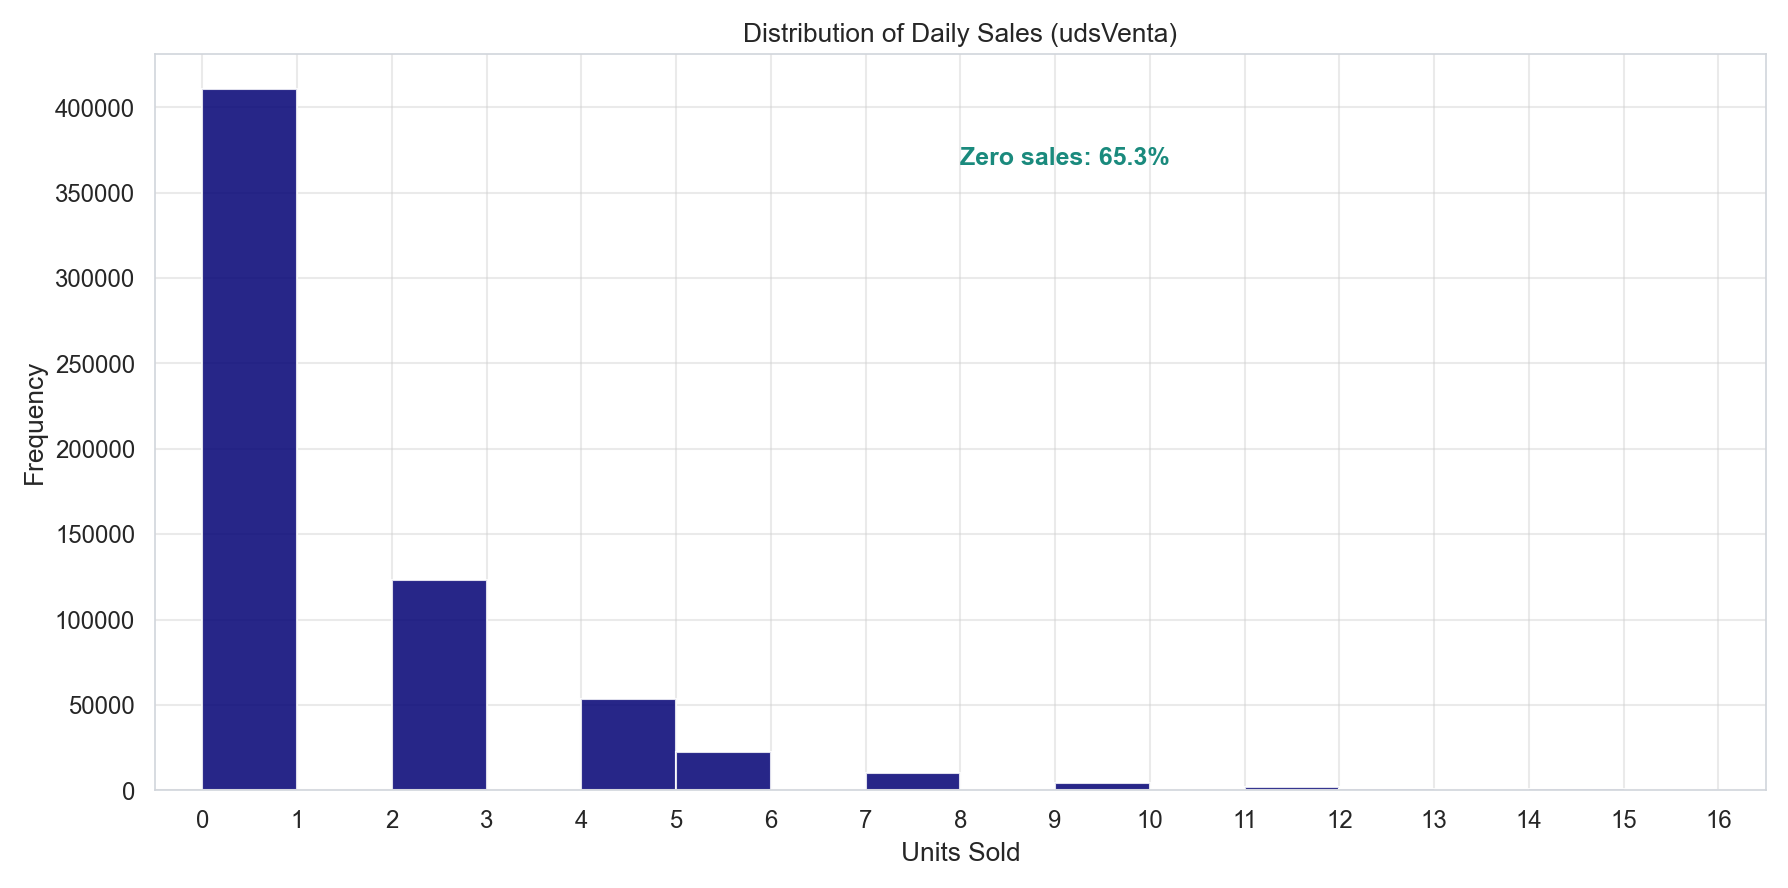

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

max_val = int(df["udsVenta"].quantile(0.999))
ax.hist(df["udsVenta"], bins=range(0, max_val + 2),
        edgecolor="white", alpha=0.85, color=PRIMARY)
ax.set_title("Distribution of Daily Sales (udsVenta)")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Frequency")
ax.set_xlim(-0.5, max_val + 0.5)
ax.set_xticks(range(0, max_val + 1))

zero_pct = 100 * (df["udsVenta"] == 0).mean()
ax.annotate(f"Zero sales: {zero_pct:.1f}%",
            xy=(0.5, 0.85), xycoords="axes fraction",
            fontsize=12, color=ACCENT, fontweight="bold")

save_fig_nb("01_sales_distribution")
plt.show()


## 5. Day-of-Week Patterns

Sales exhibit a clear weekly cycle, with the highest volumes on weekdays and near-zero sales on Sundays,
consistent with the business being closed. This motivates the use of a lag-7 naive baseline.


   → Saved 02_sales_by_day_of_week.png


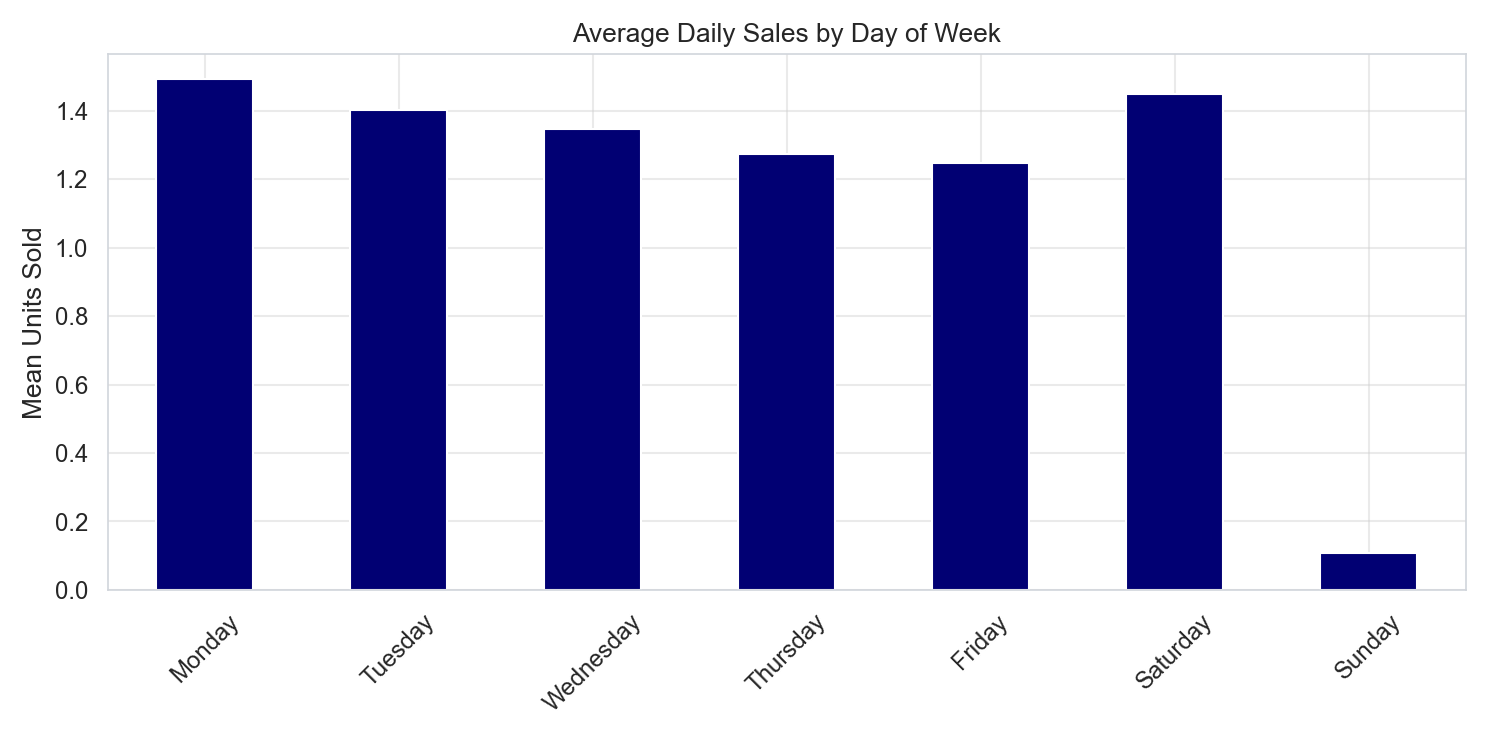

In [6]:
dow_sales = df.groupby("day_name")["udsVenta"].mean()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_sales = dow_sales.reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 5))
dow_sales.plot(kind="bar", ax=ax, color=PRIMARY, edgecolor="white")
ax.set_title("Average Daily Sales by Day of Week")
ax.set_ylabel("Mean Units Sold"); ax.set_xlabel("")
plt.xticks(rotation=45)
save_fig_nb("02_sales_by_day_of_week")
plt.show()



## 6. Monthly Patterns


   → Saved 03_sales_by_month.png


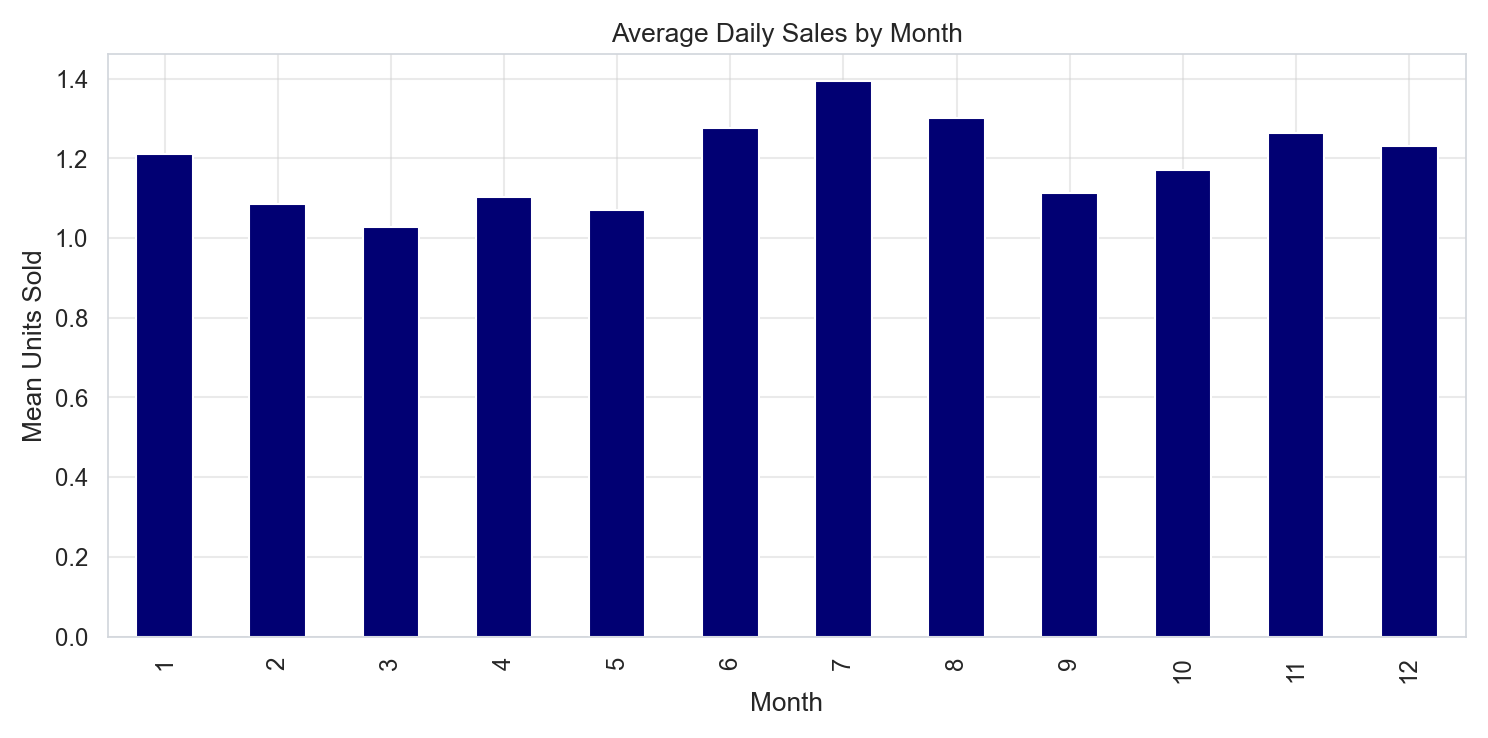

In [7]:
monthly = df.groupby("month")["udsVenta"].mean()
fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(kind="bar", ax=ax, color=PRIMARY, edgecolor="white")
ax.set_title("Average Daily Sales by Month")
ax.set_ylabel("Mean Units Sold"); ax.set_xlabel("Month")
save_fig_nb("03_sales_by_month")
plt.show()



## 7. Daily Sales Time Series


   → Saved 04_daily_sales_timeseries.png


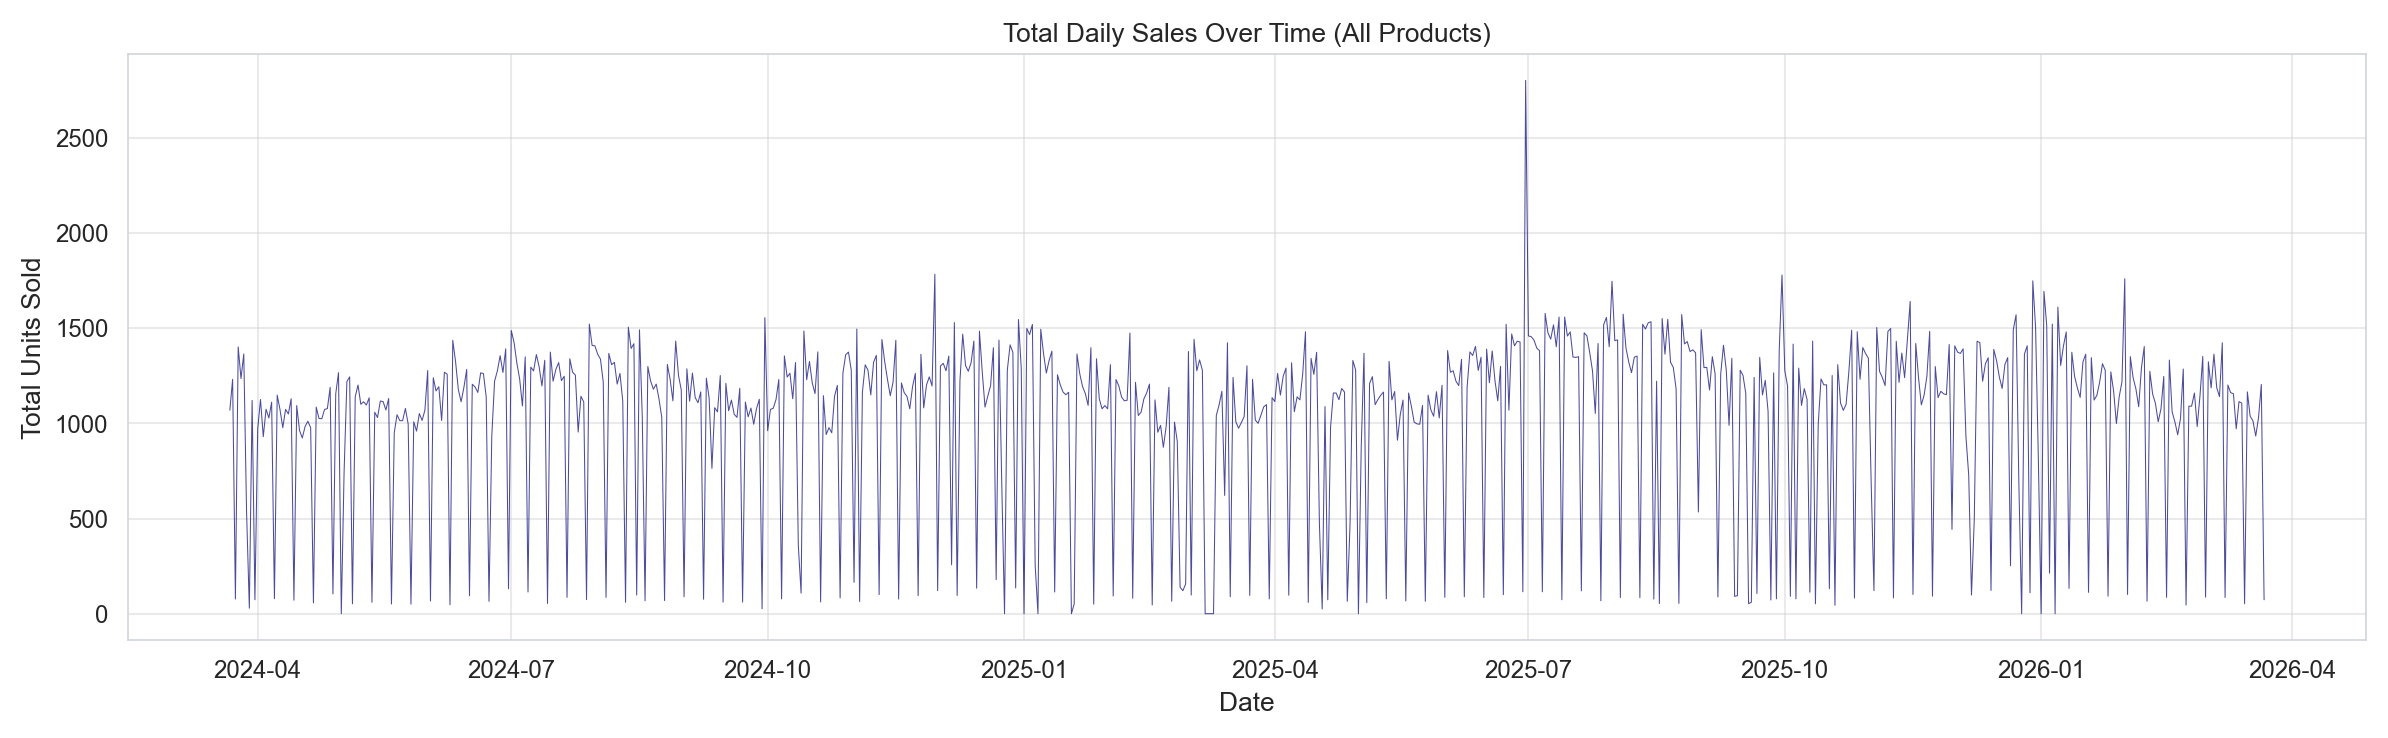

In [8]:
daily_total = df.groupby("fecha")["udsVenta"].sum()
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_total.index, daily_total.values, linewidth=0.5, alpha=0.7, color=PRIMARY)
ax.set_title("Total Daily Sales Over Time (All Products)")
ax.set_ylabel("Total Units Sold"); ax.set_xlabel("Date")
save_fig_nb("04_daily_sales_timeseries")
plt.show()



## 8. Promotional Effects

Mean sales during promotions (1.36 units) are slightly higher than during non-promotional periods (1.16 units).
The difference is modest, motivating the engineering of additional promotional features.


── Promo vs Non-Promo Sales ──
               mean  median       std   count
Non-Promo  1.160922     0.0  2.236197  546782
Promo      1.362067     0.0  2.136878   82609
   → Saved 05_promo_vs_nonpromo.png


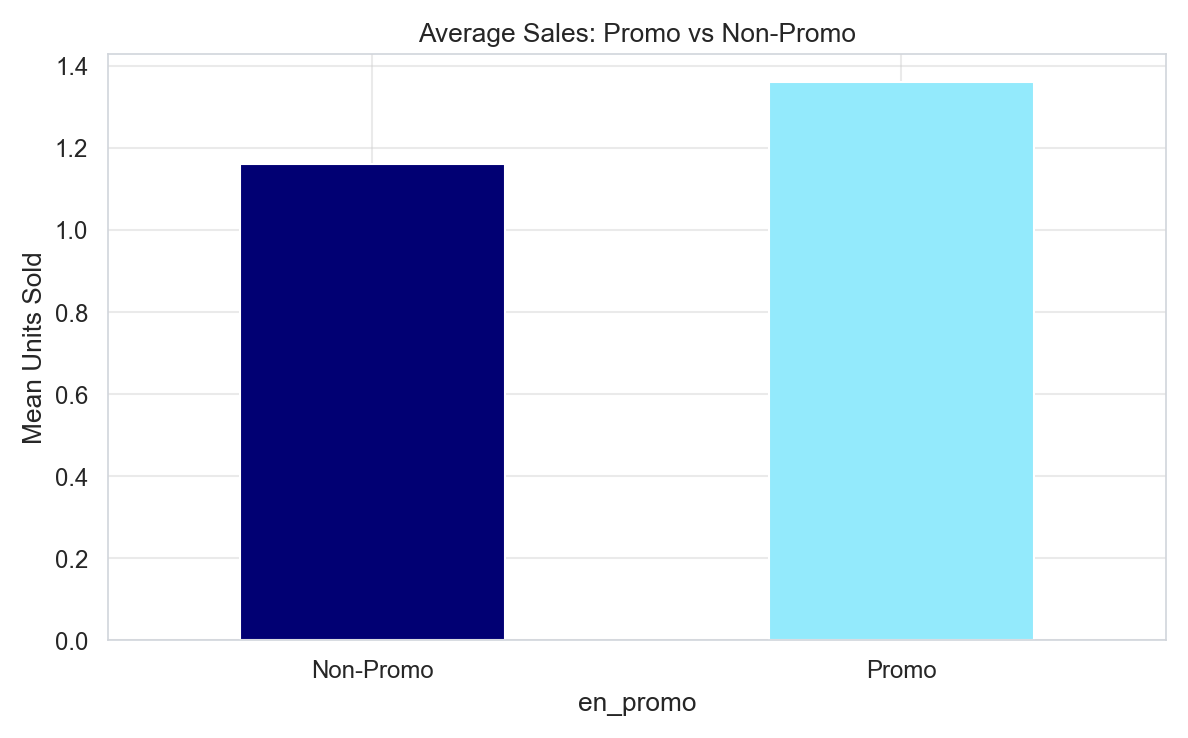

In [9]:
promo_comp = df.groupby("en_promo")["udsVenta"].agg(["mean", "median", "std", "count"])
promo_comp.index = ["Non-Promo", "Promo"]
print("── Promo vs Non-Promo Sales ──")
print(promo_comp)

fig, ax = plt.subplots(figsize=(8, 5))
df.groupby("en_promo")["udsVenta"].mean().plot(kind="bar", ax=ax, color=[PROMO_NO, PROMO_YES], edgecolor="white")
ax.set_xticklabels(["Non-Promo", "Promo"], rotation=0)
ax.set_title("Average Sales: Promo vs Non-Promo")
ax.set_ylabel("Mean Units Sold")
save_fig_nb("05_promo_vs_nonpromo")
plt.show()



## 9. Top 20 Products by Total Sales


   → Saved 06_top20_products.png


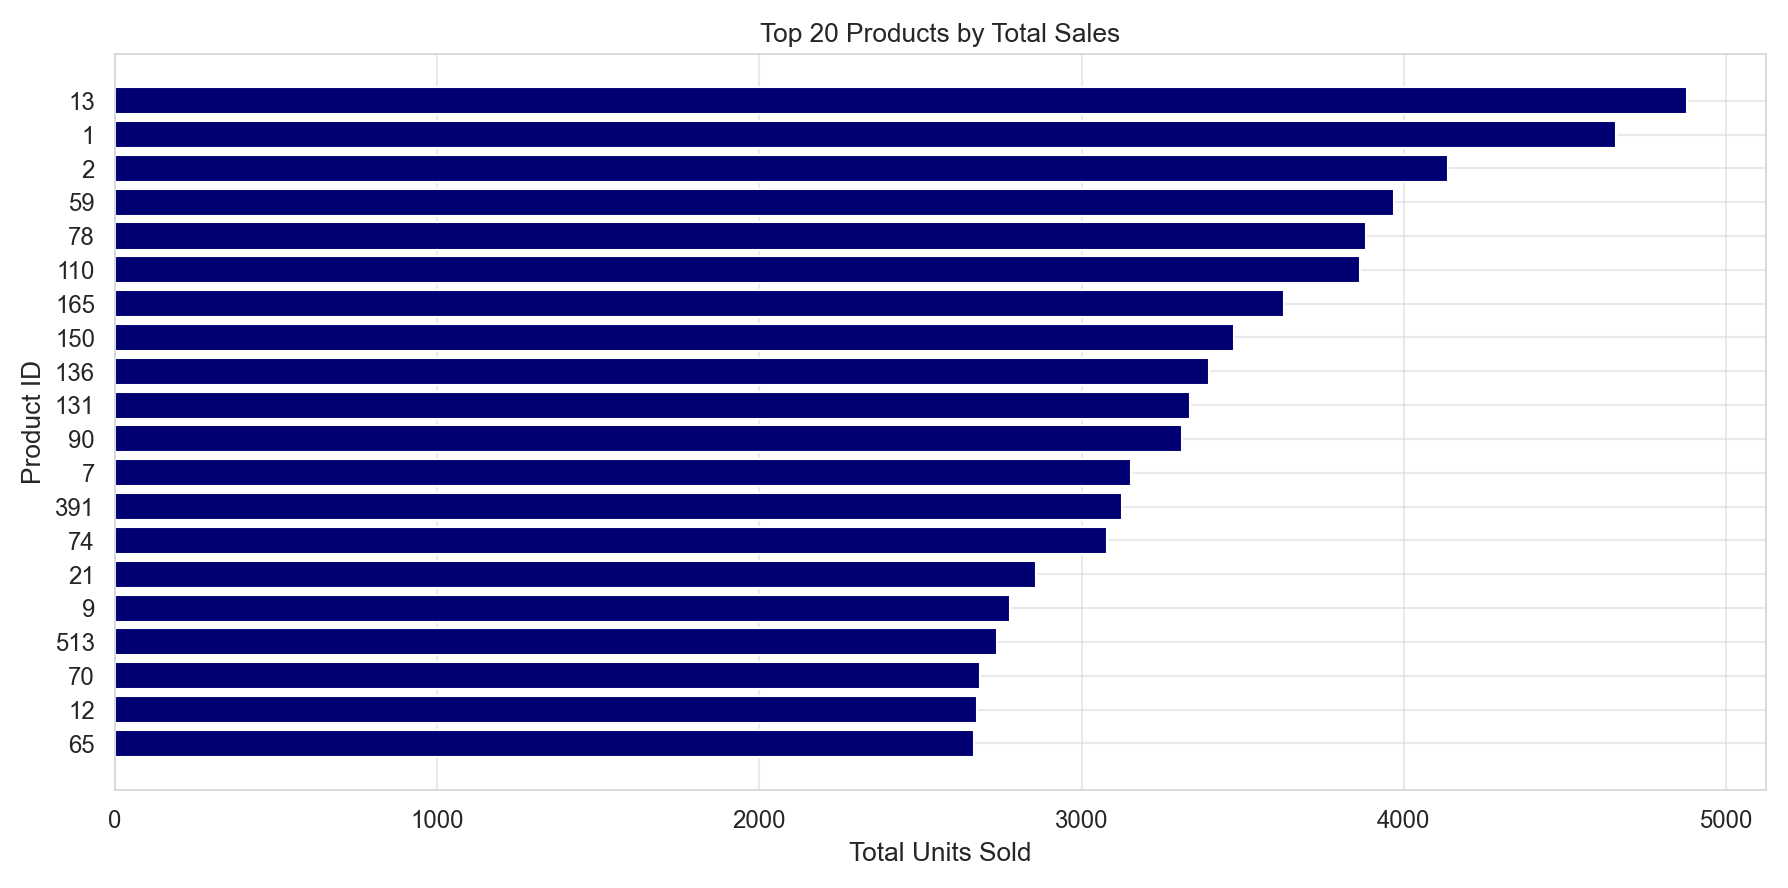

In [10]:
top20 = prod_stats.nlargest(20, "total_sales")
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top20["producto"].astype(str), top20["total_sales"], color=PRIMARY, edgecolor="white")
ax.set_title("Top 20 Products by Total Sales")
ax.set_xlabel("Total Units Sold"); ax.set_ylabel("Product ID")
ax.invert_yaxis()
save_fig_nb("06_top20_products")
plt.show()



## 10. Correlation Matrix


   → Saved 07_correlation_heatmap.png


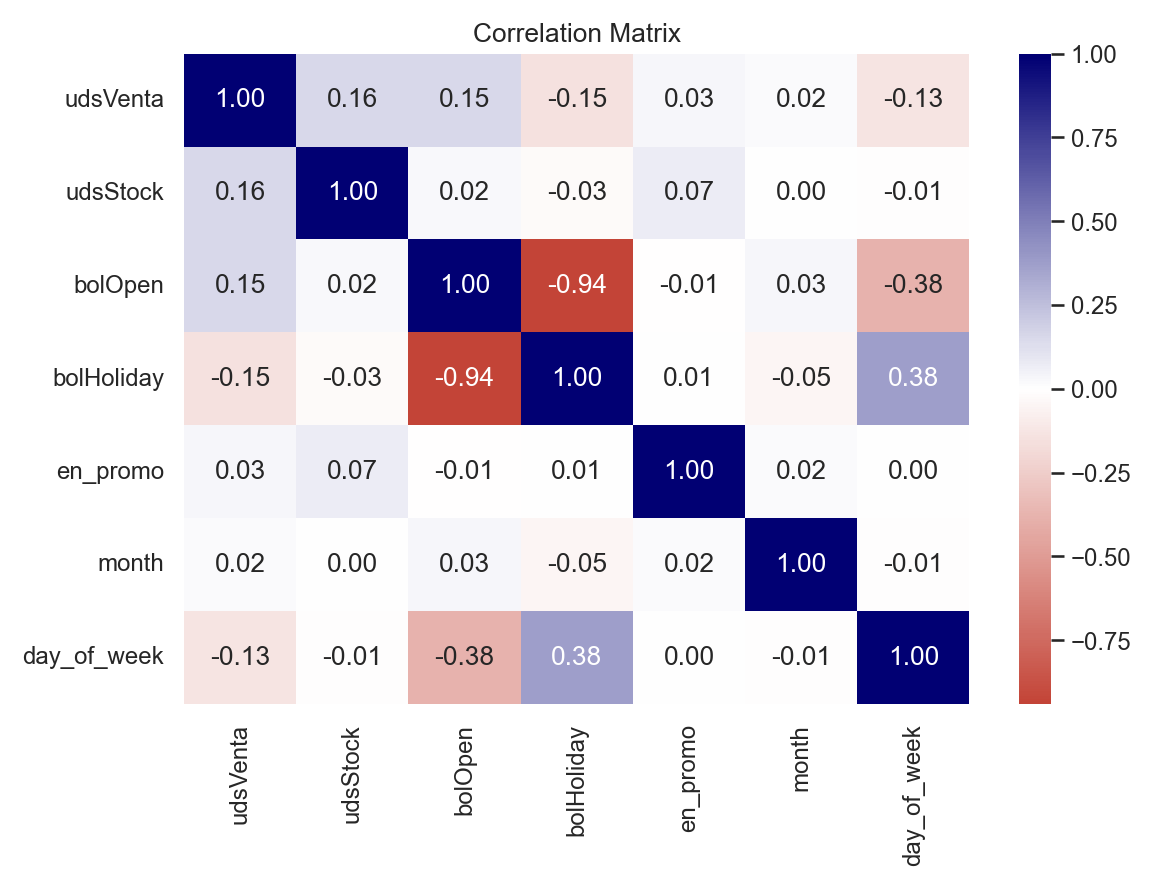

In [11]:
corr_cols = ["udsVenta", "udsStock", "bolOpen", "bolHoliday", "en_promo", "month", "day_of_week"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=UOC_CMAP, center=0, ax=ax)
ax.set_title("Correlation Matrix")
save_fig_nb("07_correlation_heatmap")
plt.show()



## 11. Autocorrelation Analysis

Autocorrelation analysis confirms significant positive autocorrelation at lags 1, 7, 14, and 28,
with the strongest signal at lag 7 (weekly periodicity). This validates the choice of lag-7 as the naive baseline
and supports the creation of lag features at these intervals.


   → Saved 08_autocorrelation_sample.png


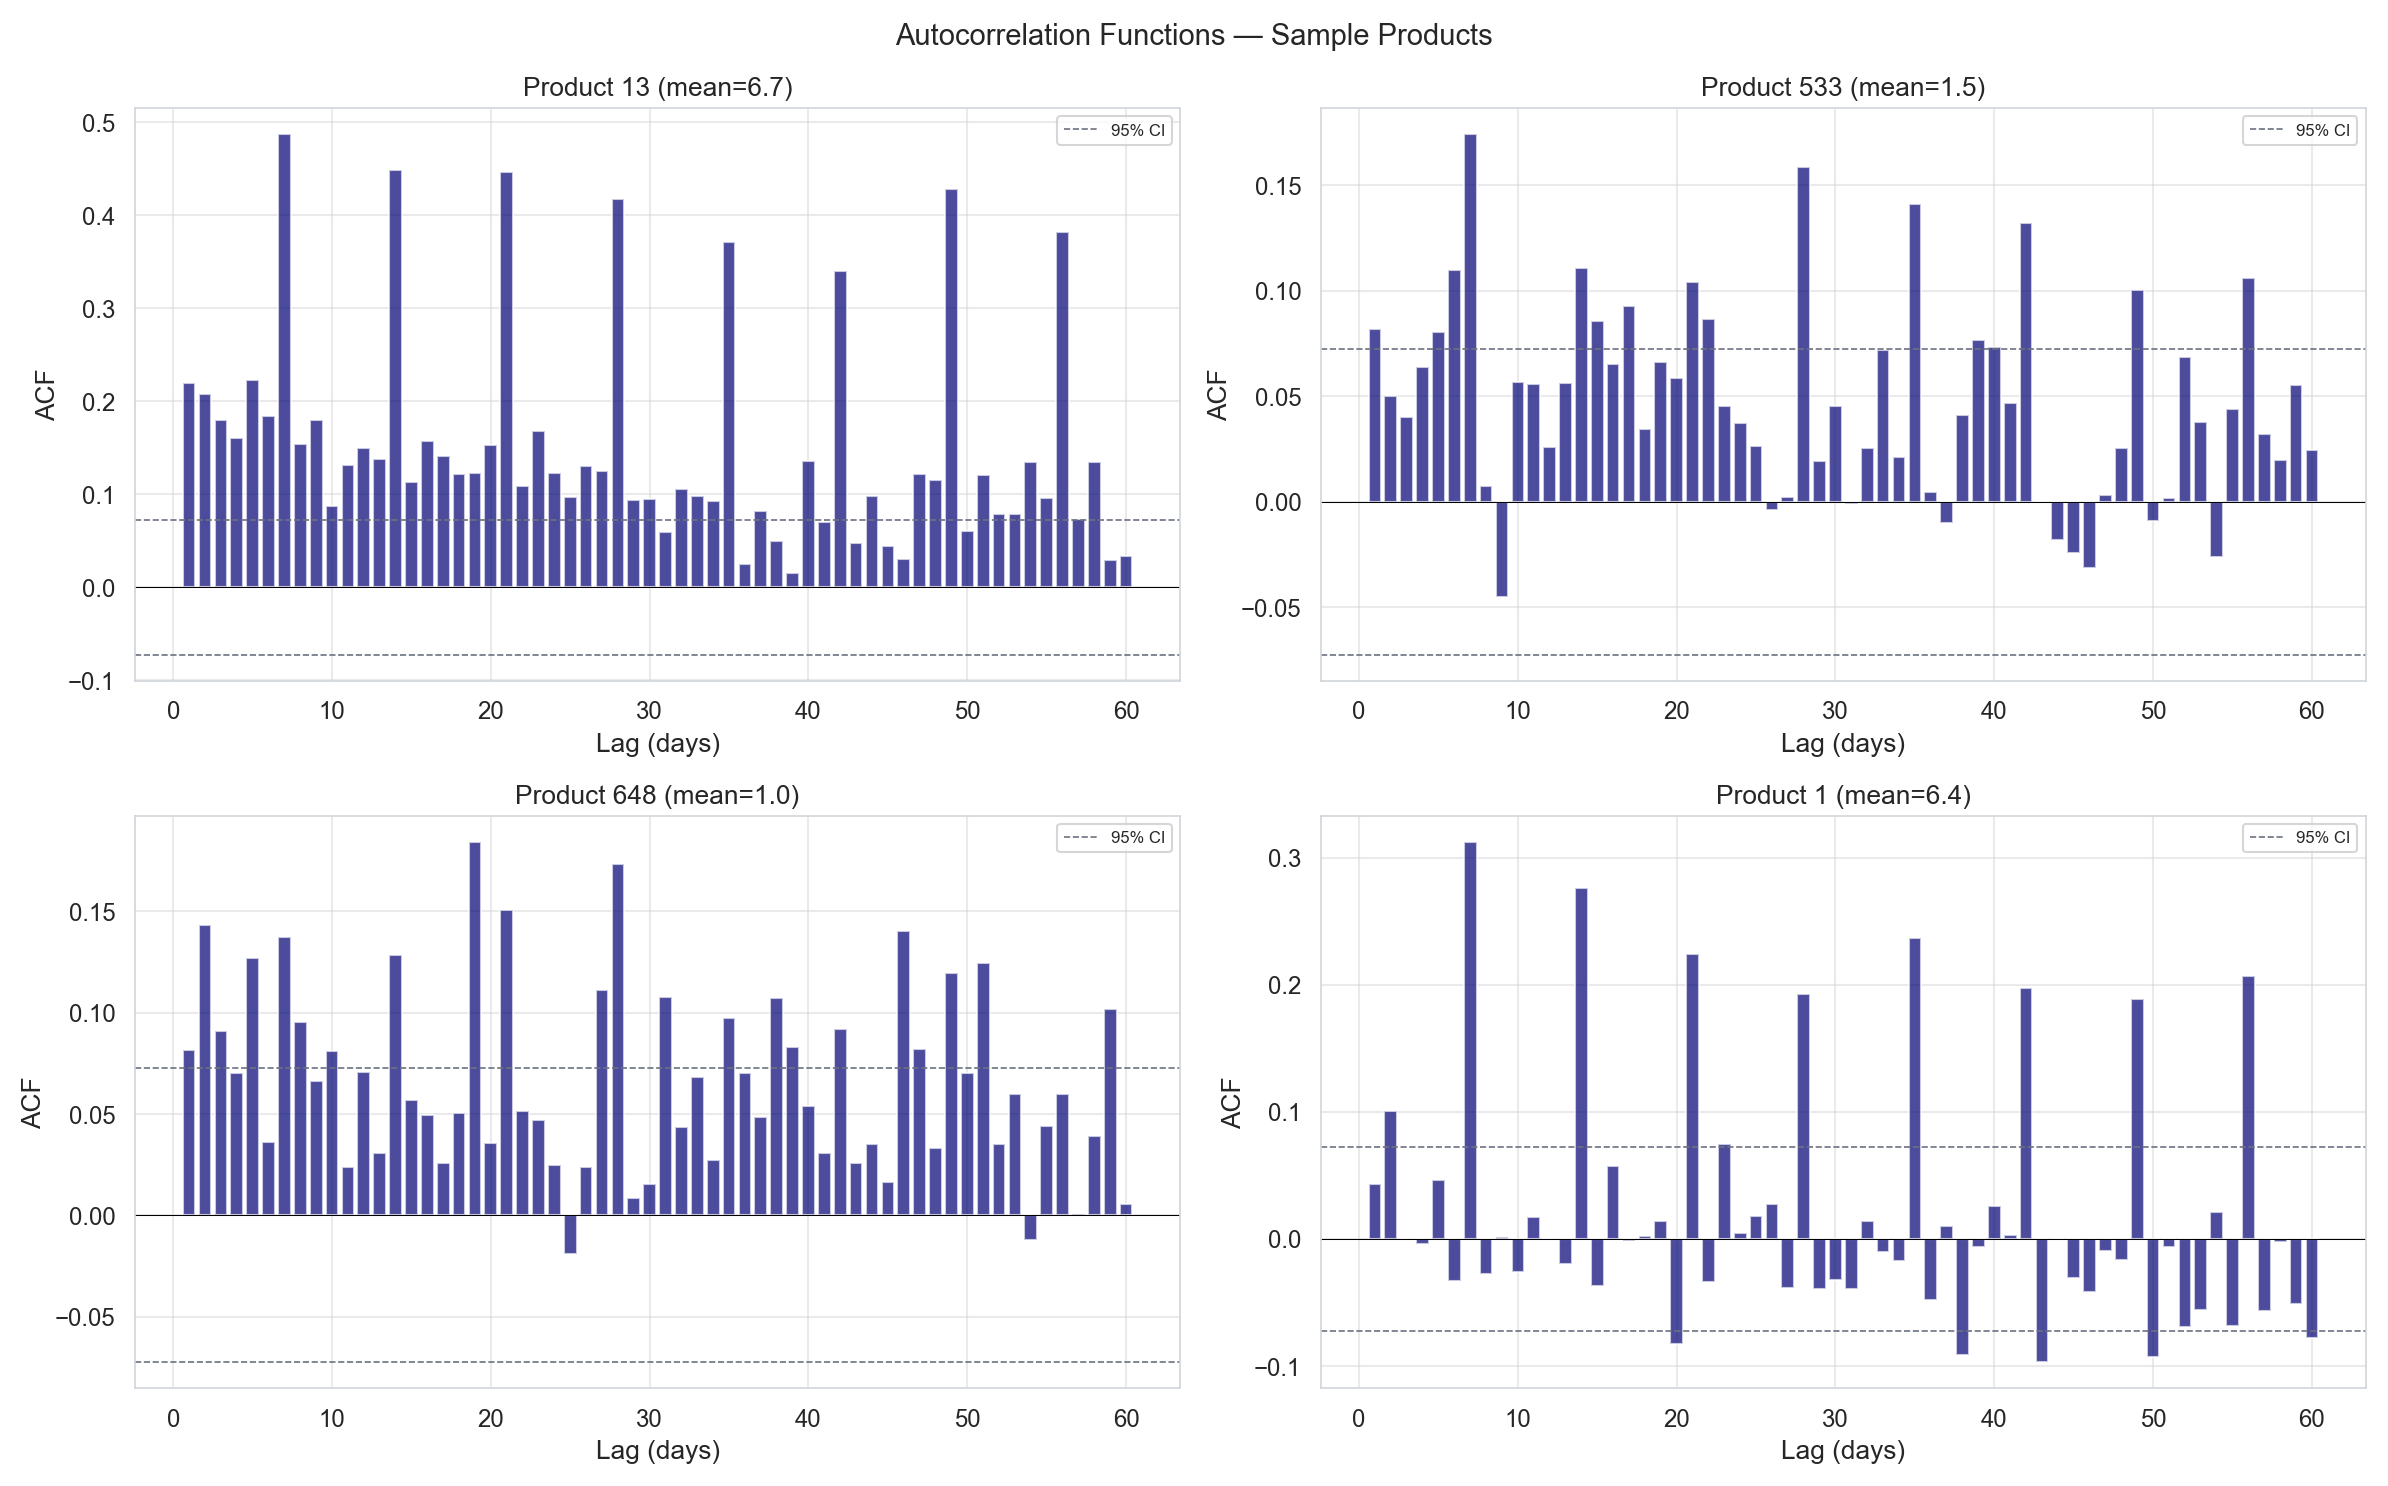

In [12]:
sorted_prods = prod_stats.sort_values("total_sales", ascending=False)
sample_products = [
    sorted_prods.iloc[0]["producto"],
    sorted_prods.iloc[len(sorted_prods)//4]["producto"],
    sorted_prods.iloc[len(sorted_prods)//2]["producto"],
    prod_stats[prod_stats["promo_pct"] > 0].sort_values("total_sales", ascending=False).iloc[0]["producto"]
]
sample_products = [int(p) for p in sample_products]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, prod_id in zip(axes.flat, sample_products):
    series = df[df["producto"] == prod_id].set_index("fecha")["udsVenta"].sort_index()
    acf_vals = [series.autocorr(lag=i) for i in range(1, 61)]
    ax.bar(range(1, 61), acf_vals, color=PRIMARY, alpha=0.7)
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.axhline(y=1.96/np.sqrt(len(series)), color=SLATE, linestyle="--", linewidth=0.8, label="95% CI")
    ax.axhline(y=-1.96/np.sqrt(len(series)), color=SLATE, linestyle="--", linewidth=0.8)
    ax.set_title(f"Product {prod_id} (mean={series.mean():.1f})")
    ax.set_xlabel("Lag (days)"); ax.set_ylabel("ACF"); ax.legend(fontsize=8)
plt.suptitle("Autocorrelation Functions — Sample Products", fontsize=14)
save_fig_nb("08_autocorrelation_sample")
plt.show()



## 12. Seasonality Patterns


Weekly pattern (0=Mon):
day_of_week
0    1.491345
1    1.402897
2    1.347181
3    1.272112
4    1.247995
5    1.447929
6    0.109076
Name: udsVenta, dtype: float64


   → Saved 09_monthly_by_year.png


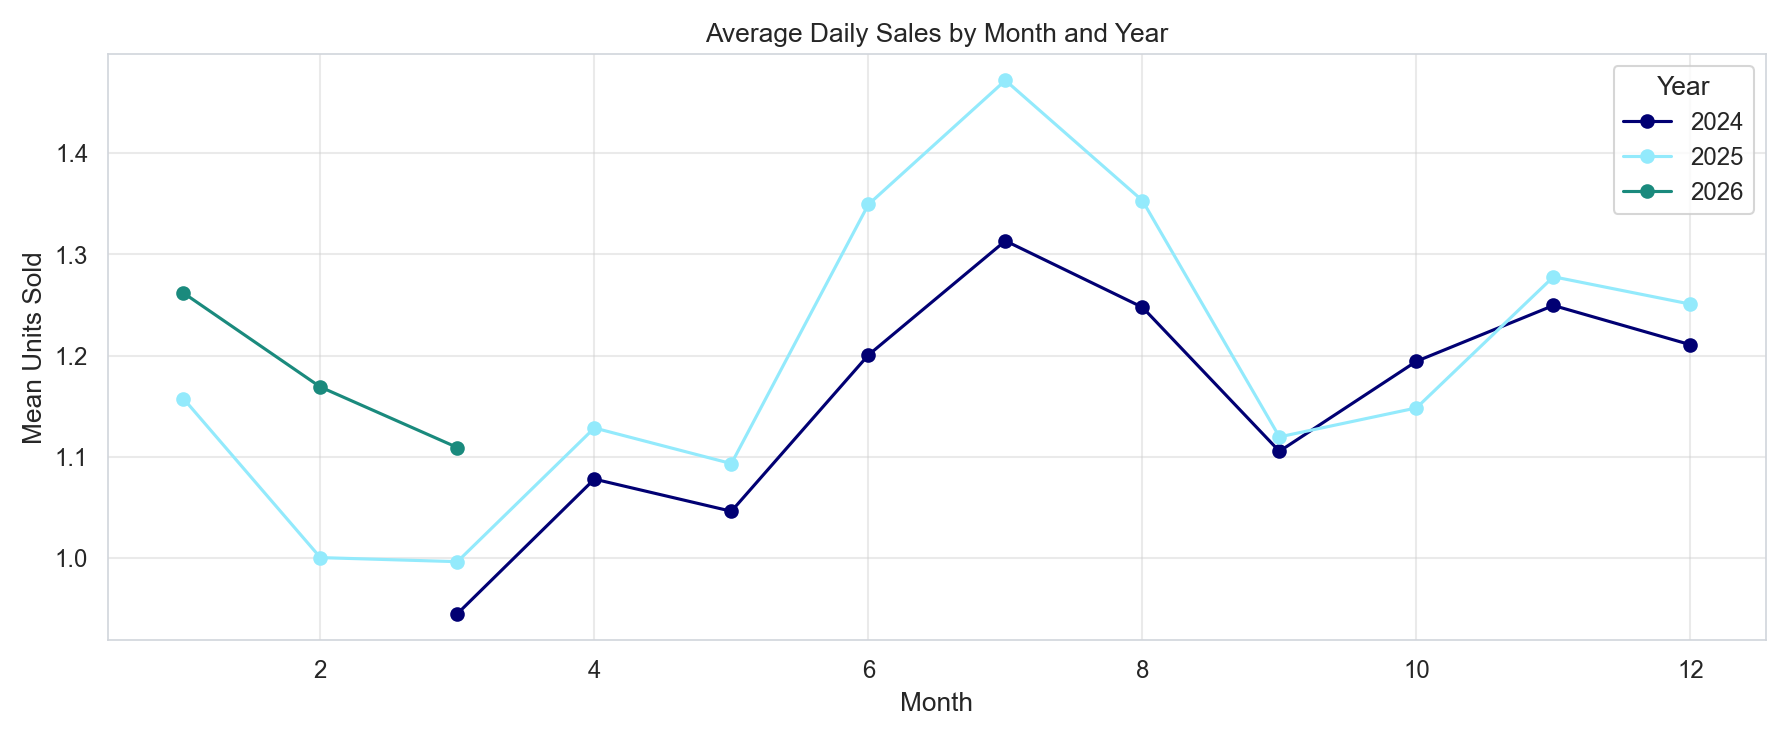

In [13]:
weekly_pattern = df.groupby("day_of_week")["udsVenta"].mean()
print("Weekly pattern (0=Mon):")
print(weekly_pattern)

monthly_year = df.groupby(["year", "month"])["udsVenta"].mean().unstack(level=0)
fig, ax = plt.subplots(figsize=(12, 5))
_year_colors = [PRIMARY, SECONDARY, ACCENT, NEUTRAL][:monthly_year.shape[1]]
monthly_year.plot(ax=ax, marker="o", color=_year_colors)
ax.set_title("Average Daily Sales by Month and Year")
ax.set_xlabel("Month"); ax.set_ylabel("Mean Units Sold")
ax.legend(title="Year")
save_fig_nb("09_monthly_by_year")
plt.show()



## 13. Data Quality Summary

Summary of data quality findings:
- No negative sales or stock values
- 65.3% zero-sales observations
- 2.0% stock breaks (sales=0 & stock=0)
- 861 missing calendar entries (1 day)


In [14]:
neg_sales = (df["udsVenta"] < 0).sum()
neg_stock = (df["udsStock"] < 0).sum()
zero_sales = (df["udsVenta"] == 0).sum()
missing_cal = df["bolOpen"].isnull().sum()

print(f"Total rows:           {len(df):,}")
print(f"Products:             {df['producto'].nunique()}")
print(f"Date range:           {df['fecha'].min().date()} → {df['fecha'].max().date()}")
print(f"Days:                 {df['fecha'].nunique()}")
print(f"Negative sales:       {neg_sales:,}")
print(f"Negative stock:       {neg_stock:,}")
print(f"Zero sales:           {zero_sales:,} ({100*zero_sales/len(df):.1f}%)")
print(f"Stock breaks:         {stock_breaks.sum():,} ({100*stock_breaks.mean():.1f}%)")
print(f"Missing calendario:   {missing_cal}")
print(f"Promo observations:   {df['en_promo'].sum():,} ({100*df['en_promo'].mean():.1f}%)")

PROCESSED_DIR = Path(".") / "output" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df.to_parquet(PROCESSED_DIR / "merged_raw.parquet", index=False)
print(f"\n✓ Merged dataframe saved to output/processed/merged_raw.parquet")



Total rows:           629,391
Products:             861
Date range:           2024-03-22 → 2026-03-22
Days:                 731
Negative sales:       0
Negative stock:       0
Zero sales:           410,794 (65.3%)
Stock breaks:         12,544 (2.0%)
Missing calendario:   861
Promo observations:   82,609 (13.1%)



✓ Merged dataframe saved to output/processed/merged_raw.parquet
